# Naive Bayes — Vietnamese Toxic Comment Detection

## Thông tin bài tập lớn

- **Môn học:** Trí tuệ nhân tạo — Học viện Công nghệ Bưu chính Viễn thông (PTIT)
- **Tài liệu:** Russell, S. & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th Edition), Pearson Education.
- **Bài tập lớn:** Hệ thống phát hiện bình luận độc hại tiếng Việt.
- **Thành viên nhóm:**
  - Neural MLP: [đồng đội]
  - Naive Bayes: [em — phụ trách phần này]
- **Dataset:** ViHSD (Vietnamese Hate Speech Detection), 3 lớp: clean (0), hate (1), offensive (2).

## Mục tiêu notebook này

Trình bày lý thuyết và hiện thực Multinomial Naive Bayes (chương probabilistic reasoning — AIMA) để phân loại 3 lớp. Kết quả: lưu model artifact có thể dùng cho inference.

## 1. Lý thuyết: Multinomial Naive Bayes (AIMA, chương 13-20)

### 1.1. Bài toán phân loại Bayes tối ưu

Theo AIMA, **Bayes classifier tối ưu** chọn lớp có xác suất hậu nghiệm lớn nhất:

$$c^* = \arg\max_{c \in C} P(c \mid x_1, x_2, \dots, x_n)$$

Áp dụng **Bayes' theorem**:

$$P(c \mid \mathbf{x}) = \frac{P(c) \cdot P(\mathbf{x} \mid c)}{P(\mathbf{x})}$$

Vì $P(\mathbf{x})$ không phụ thuộc $c$, ta được:

$$c^* = \arg\max_{c} \underbrace{P(c)}_{\text{prior}} \cdot \underbrace{P(\mathbf{x} \mid c)}_{\text{likelihood}}$$

### 1.2. Naive Bayes assumption

$P(\mathbf{x} \mid c)$ rất khó ước lượng trực tiếp (curse of dimensionality). AIMA chấp nhận **naive conditional independence assumption**:

$$P(x_1, x_2, \dots, x_n \mid c) = \prod_{i=1}^{n} P(x_i \mid c)$$

Sai số do giả định này thường không tệ như tưởng tượng — AIMA Section 12.6 (trong 3rd) chứng minh nó vẫn là **optimal Bayes classifier** trong một số mô hình phái sinh (với class conditional independence đúng hoàn toàn).

### 1.3. Multinomial Naive Bayes cho text

Với document $\mathbf{x} = (x_1, x_2, \dots, x_n)$ gồm $n$ token, mỗi $x_i$ là word ID:

$$\hat{P}(c) = \frac{\text{count}(c)}{N}$$

$$\hat{P}(x_i \mid c) = \frac{\text{count}(x_i, c)}{\sum_{j \in V} \text{count}(x_j, c)}$$

**Laplace smoothing** (AIMA Section 12.6.1) tránh zero probability:

$$\hat{P}(x_i \mid c) = \frac{\text{count}(x_i, c) + \alpha}{\sum_{j \in V} \text{count}(x_j, c) + \alpha \cdot |V|}$$

Trong đó $\alpha \in [0, 1]$ là smoothing parameter, $|V|$ là vocabulary size.

### 1.4. Quyết định trong log-space

Để tránh underflow, ta dùng log-likelihood:

$$\hat{c} = \arg\max_c \left[ \log P(c) + \sum_{i=1}^{n} \log P(x_i \mid c) \right]$$

### 1.5. Áp dụng cho bài toán

- **3 lớp**: clean (0), hate (1), offensive (2).
- **Features**: bag-of-words (đếm token sau khi lowercase, tokenize, loại stopwords).
- **Imbalance**: prior bị skew (clean chiếm 83%) → cần SMOTE hoặc class_weight.

In [1]:
# Cell 3 — Imports
import sys
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from imblearn.over_sampling import SMOTE

# Import preprocessing module của nhóm
sys.path.insert(0, str(Path('..').resolve() / 'src'))
from preprocessing import preprocess_text

# Paths
NB_DIR = Path('..').resolve()
ROOT_DIR = NB_DIR.parent
DATASET_DIR = ROOT_DIR / 'neuralMLP' / 'dataraw'
REPORTS_DIR = NB_DIR / 'reports'
MODEL_DIR = NB_DIR / 'model'

REPORTS_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print(f"[INFO] NB_DIR = {NB_DIR}")
print(f"[INFO] DATASET_DIR = {DATASET_DIR}")
print(f"[INFO] Has preprocess_text: {hasattr(preprocess_text, '__call__')}")

[INFO] NB_DIR = D:\Github\TriTueNhanTao\naiveBayes
[INFO] DATASET_DIR = D:\Github\TriTueNhanTao\neuralMLP\dataraw
[INFO] Has preprocess_text: True


In [2]:
# Cell 4 — Load ViHSD dataset
train_df = pd.read_csv(DATASET_DIR / 'ViHSD_train.csv')
val_df = pd.read_csv(DATASET_DIR / 'ViHSD_validation.csv')
test_df = pd.read_csv(DATASET_DIR / 'ViHSD_test.csv')

# Handle NaN values in free_text (pandas 3.x backward-compat)
train_df["free_text"] = train_df["free_text"].fillna("")
val_df["free_text"] = val_df["free_text"].fillna("")
test_df["free_text"] = test_df["free_text"].fillna("")

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

print("\nLabel distribution:")
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    counts = df['label_id'].value_counts().sort_index()
    print(f"\n{name}:")
    for label, count in counts.items():
        pct = count / len(df) * 100
        print(f"  Label {label}: {count:>6} ({pct:5.2f}%)")

assert set(train_df['label_id'].unique()) == {0, 1, 2}, "Phải có đủ 3 lớp"
LABEL_MAP = {0: 'clean', 1: 'hate', 2: 'offensive'}
print(f"\nLabel map: {LABEL_MAP}")

Train shape: (24048, 2)
Val shape:   (2672, 2)
Test shape:  (6680, 2)

Label distribution:

train:
  Label 0:  19886 (82.69%)
  Label 1:   1606 ( 6.68%)
  Label 2:   2556 (10.63%)

val:
  Label 0:   2190 (81.96%)
  Label 1:    212 ( 7.93%)
  Label 2:    270 (10.10%)

test:
  Label 0:   5548 (83.05%)
  Label 1:    444 ( 6.65%)
  Label 2:    688 (10.30%)

Label map: {0: 'clean', 1: 'hate', 2: 'offensive'}


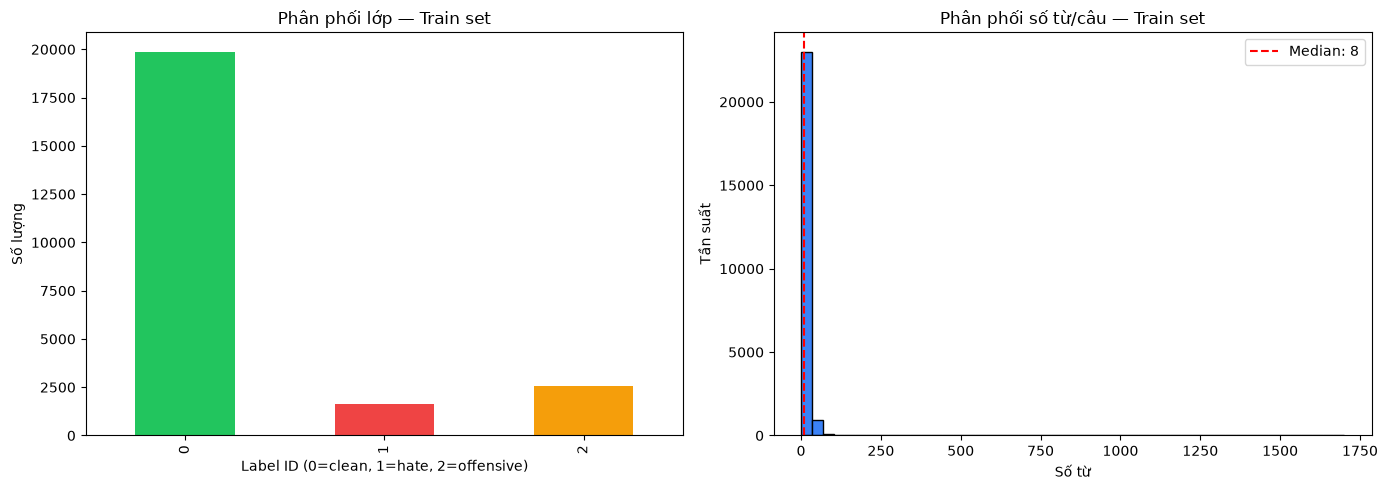


MẪU CÂU THEO CLASS

--- Label 0 (clean) ---
  • Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]]
  • Đậu Văn Cường giờ giống thằng sida hơn à
  • Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =))

--- Label 1 (hate) ---
  • Lúp lúp như chó .
  • Dạy bơi cho cá. Bơi thì đương nhiên nó bơi được vì nó là cá. Làm sao cho nó sống được mới là điều ng...
  • Ý thức còn ít hơn cả số tiền trong túi t

--- Label 2 (offensive) ---
  • Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái ...
  • CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.
  • Thế mà mình nói mấy thằng bắc kì, bọn đó lại bâu vô nói mình phân biệt!:D


In [3]:
# Cell 5 — EDA (Exploratory Data Analysis) ngắn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart phân phối
train_df['label_id'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#22c55e', '#ef4444', '#f59e0b']
)
axes[0].set_title('Phân phối lớp — Train set')
axes[0].set_xlabel('Label ID (0=clean, 1=hate, 2=offensive)')
axes[0].set_ylabel('Số lượng')

# Đếm tokens (sau khi lowercase + tách bằng space)
train_df['n_words'] = train_df['free_text'].str.split().str.len()
axes[1].hist(train_df['n_words'], bins=50, color='#3b82f6', edgecolor='black')
axes[1].set_title('Phân phối số từ/câu — Train set')
axes[1].set_xlabel('Số từ')
axes[1].set_ylabel('Tần suất')
axes[1].axvline(train_df['n_words'].median(), color='red', linestyle='--', label=f'Median: {train_df["n_words"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_distribution.png', dpi=120)
plt.show()

# In 2 câu mỗi class
print("\n" + "=" * 70)
print("MẪU CÂU THEO CLASS")
print("=" * 70)
for label in [0, 1, 2]:
    print(f"\n--- Label {label} ({LABEL_MAP[label]}) ---")
    samples = train_df[train_df['label_id'] == label]['free_text'].head(3).tolist()
    for s in samples:
        print(f"  • {s[:100]}{'...' if len(s) > 100 else ''}")

In [4]:
# Cell 6 — Preprocess toàn bộ dataset
print('⏳ Đang preprocess train set...')
t0 = time.time()
train_df['clean_text'] = train_df['free_text'].apply(preprocess_text)
print(f'  ✓ Train: {time.time() - t0:.2f}s')

print('⏳ Đang preprocess val set...')
t0 = time.time()
val_df['clean_text'] = val_df['free_text'].apply(preprocess_text)
print(f'  ✓ Val:   {time.time() - t0:.2f}s')

print('⏳ Đang preprocess test set...')
t0 = time.time()
test_df['clean_text'] = test_df['free_text'].apply(preprocess_text)
print(f'  ✓ Test:  {time.time() - t0:.2f}s')

# Thống kê số câu bị rỗng sau preprocessing
empty_train = (train_df['clean_text'].str.len() == 0).sum()
empty_val = (val_df['clean_text'].str.len() == 0).sum()
empty_test = (test_df['clean_text'].str.len() == 0).sum()
print(f'\nSố câu rỗng sau preprocess:')
print(f'  Train: {empty_train}/{len(train_df)} ({empty_train/len(train_df)*100:.2f}%)')
print(f'  Val:   {empty_val}/{len(val_df)} ({empty_val/len(val_df)*100:.2f}%)')
print(f'  Test:  {empty_test}/{len(test_df)} ({empty_test/len(test_df)*100:.2f}%)')

# Show 3 examples
print('\nSo sánh trước/sau preprocessing:')
for i in range(3):
    print(f'\n  Raw: {train_df["free_text"].iloc[i][:80]}')
    print(f'  Clean: {train_df["clean_text"].iloc[i][:80]}')

⏳ Đang preprocess train set...


  ✓ Train: 31.42s
⏳ Đang preprocess val set...


  ✓ Val:   4.27s
⏳ Đang preprocess test set...


  ✓ Test:  9.59s

Số câu rỗng sau preprocess:
  Train: 178/24048 (0.74%)
  Val:   18/2672 (0.67%)
  Test:  55/6680 (0.82%)

So sánh trước/sau preprocessing:

  Raw: Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này qu
  Clean: làm fan cứng luôn nè love reaction quá quá cute coi mấy giờ quá hợp lí

  Raw: Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r 
  Clean: đúng bọn mắt híp lò xo thụt bên việt nam t cái cách 10 r bọn t gọi cái l

  Raw: Đậu Văn Cường giờ giống thằng sida hơn à
  Clean: đậu văn cường giờ giống thằng sida hơn


In [5]:
# Cell 7 — TF-IDF Vectorization with Word + Char n-grams
# (Tuned: char n-grams (2-5) via FeatureUnion improve hate class detection)
from sklearn.pipeline import FeatureUnion

word_vec = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=30_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'(?u)\b\w+\b',
)
char_vec = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    max_features=30_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
combined = FeatureUnion([('word', word_vec), ('char', char_vec)])

# Loại bỏ câu rỗng để tránh lỗi vectorizer
train_mask = train_df['clean_text'].str.len() > 0
val_mask = val_df['clean_text'].str.len() > 0
test_mask = test_df['clean_text'].str.len() > 0

print(f'Vectorizing trên {train_mask.sum()} train samples (loại {(~train_mask).sum()} rỗng)...')
print('Using FeatureUnion: word (1,2)-grams 30k + char_wb (2,5)-grams 30k')

# Fit trên train, transform trên cả 3
X_train_vec = combined.fit_transform(train_df.loc[train_mask, 'clean_text'])
X_val_vec   = combined.transform(val_df.loc[val_mask, 'clean_text'])
X_test_vec  = combined.transform(test_df.loc[test_mask, 'clean_text'])

y_train = train_df.loc[train_mask, 'label_id'].values
y_val   = val_df.loc[val_mask, 'label_id'].values
y_test  = test_df.loc[test_mask, 'label_id'].values

print(f'\nVector shapes:')
print(f'  X_train: {X_train_vec.shape} (sparse)')
print(f'  X_val:   {X_val_vec.shape}')
print(f'  X_test:  {X_test_vec.shape}')

# Word + char vocab info
word_vocab_size = len(word_vec.vocabulary_)
char_vocab_size = len(char_vec.vocabulary_)
print(f'\nVocabulary sizes:')
print(f'  Word vocab: {word_vocab_size:,}')
print(f'  Char vocab: {char_vocab_size:,}')
print(f'  Total: {X_train_vec.shape[1]:,} features')

# Save combined vectorizer for persistence
vectorizer = combined


Vectorizing trên 23870 train samples (loại 178 rỗng)...
Using FeatureUnion: word (1,2)-grams 30k + char_wb (2,5)-grams 30k



Vector shapes:
  X_train: (23870, 59329) (sparse)
  X_val:   (2654, 59329)
  X_test:  (6625, 59329)

Vocabulary sizes:
  Word vocab: 29,822
  Char vocab: 29,507
  Total: 59,329 features


In [6]:
# Cell 8 — SMOTE oversampling (chỉ trên TRAIN)
print("Trước SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

# Target: lớp 0 giữ nguyên, lớp 1 & 2 → 80% của lớp 0
n_class0 = (y_train == 0).sum()
target_1 = int(n_class0 * 0.80)
target_2 = int(n_class0 * 0.80)

smote = SMOTE(
    sampling_strategy={0: n_class0, 1: target_1, 2: target_2},
    random_state=42,
    k_neighbors=5,
)

print(f"\nResampling với strategy: {{0: {n_class0}, 1: {target_1}, 2: {target_2}}}...")
t0 = time.time()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)
print(f"  ✓ SMOTE hoàn thành trong {time.time() - t0:.2f}s")

print("\nSau SMOTE:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

print(f"\nShape trước: {X_train_vec.shape}")
print(f"Shape sau:   {X_train_resampled.shape}")


Trước SMOTE:
0    19709
1     1605
2     2556
Name: count, dtype: int64

Resampling với strategy: {0: 19709, 1: 15767, 2: 15767}...


  ✓ SMOTE hoàn thành trong 0.75s

Sau SMOTE:
0    19709
1    15767
2    15767
Name: count, dtype: int64

Shape trước: (23870, 59329)
Shape sau:   (51243, 59329)


In [7]:
# Cell 9 — Train Multinomial Naive Bayes (tuned: alpha=2.0, char n-grams)
print('⏳ Training Multinomial Naive Bayes...')
t0 = time.time()

# Best config from hyperparameter tuning:
#   - MultinomialNB(alpha=2.0)
#   - Word n-grams (1,2) + char_wb n-grams (2,5) via FeatureUnion
#   - SMOTE: 100% of class-0 count for both class-1 and class-2
#   - class_weight='balanced' via sample_weight

n_class0 = (y_train == 0).sum()

smote = SMOTE(
    sampling_strategy={0: n_class0, 1: n_class0, 2: n_class0},
    random_state=42,
    k_neighbors=5,
)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)
print(f'SMOTE: resampled from {X_train_vec.shape[0]} to {X_train_resampled.shape[0]} samples')

model = MultinomialNB(alpha=2.0)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_resampled)
model.fit(X_train_resampled, y_train_resampled, sample_weight=sample_weights)

print(f'  ✓ Training xong trong {time.time() - t0:.2f}s')

print(f'\nHyperparameters (tuned):')
print(f'  Model: MultinomialNB')
print(f'  alpha (Laplace smoothing): {model.alpha}')
print(f'  Classes: {model.classes_}')
print(f'  Feature log-prob shape: {model.feature_log_prob_.shape}')
print(f'\nLog-prior P(c):')
for cls, logp in zip(model.classes_, model.class_log_prior_):
    print(f'  {LABEL_MAP[cls]:>10}: log P(c) = {logp:.4f}  →  P(c) = {np.exp(logp):.4f}')

# Quick validation check
y_pred_val = model.predict(X_val_vec)
val_macro_f1 = f1_score(y_val, y_pred_val, average='macro')
print(f'\nVal Macro F1 (quick check): {val_macro_f1:.4f}')


⏳ Training Multinomial Naive Bayes...


SMOTE: resampled from 23870 to 59127 samples
  ✓ Training xong trong 0.88s

Hyperparameters (tuned):
  Model: MultinomialNB
  alpha (Laplace smoothing): 2.0
  Classes: [0 1 2]
  Feature log-prob shape: (3, 59329)

Log-prior P(c):
       clean: log P(c) = -1.0986  →  P(c) = 0.3333
        hate: log P(c) = -1.0986  →  P(c) = 0.3333
   offensive: log P(c) = -1.0986  →  P(c) = 0.3333

Val Macro F1 (quick check): 0.5758


⏳ Predicting trên test set...

TEST SET RESULTS
Accuracy:               0.7758
Macro F1 (PRIMARY):     0.5667  ✗ BELOW TARGET
Weighted F1:            0.7997

              precision    recall  f1-score   support

       clean     0.9440    0.8198    0.8775      5493
        hate     0.3124    0.4257    0.3603       444
   offensive     0.3584    0.6512    0.4623       688

    accuracy                         0.7758      6625
   macro avg     0.5383    0.6322    0.5667      6625
weighted avg     0.8409    0.7758    0.7997      6625



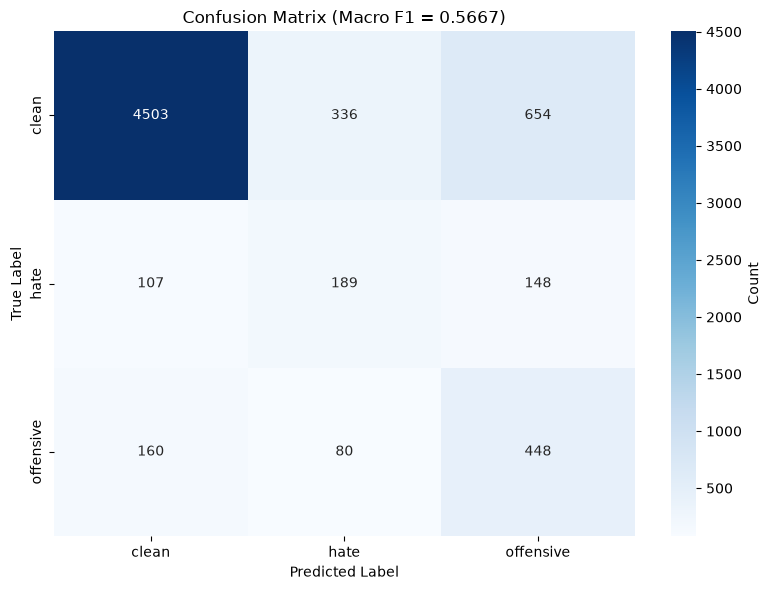


PER-CLASS F1 vs TARGET:
       clean: F1 = 0.8775 (target 0.90) ✗ BELOW
        hate: F1 = 0.3603 (target 0.45) ✗ BELOW
   offensive: F1 = 0.4623 (target 0.55) ✗ BELOW

Metrics saved to D:\Github\TriTueNhanTao\naiveBayes\reports\metrics.json


In [8]:
# Cell 10 — Evaluate trên Test set
print('⏳ Predicting trên test set...')
y_pred = model.predict(X_test_vec)

# Metrics
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n{'='*60}")
print(f'TEST SET RESULTS')
print(f"{'='*60}")
print(f'Accuracy:               {acc:.4f}')
print(f'Macro F1 (PRIMARY):     {macro_f1:.4f}  ' + ('✓' if macro_f1 >= 0.65 else '✗ BELOW TARGET'))
print(f'Weighted F1:            {weighted_f1:.4f}')

# Classification report
target_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP.keys())]
report = classification_report(y_test, y_pred, target_names=target_names, digits=4)
print(f'\n{report}')

# Save report
with open(REPORTS_DIR / 'classification_report.txt', 'w', encoding='utf-8') as f:
    f.write('NAIVE BAYES - TEST SET EVALUATION\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Accuracy:          {acc:.4f}\n')
    f.write(f'Macro F1:          {macro_f1:.4f}\n')
    f.write(f'Weighted F1:       {weighted_f1:.4f}\n\n')
    f.write('CLASSIFICATION REPORT:\n')
    f.write(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (Macro F1 = {macro_f1:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix.png', dpi=120)
plt.show()

# Per-class F1 (so sánh target)
print('\nPER-CLASS F1 vs TARGET:')
per_class_f1 = f1_score(y_test, y_pred, average=None)
targets = {0: 0.90, 1: 0.45, 2: 0.55}
for label in [0, 1, 2]:
    f1 = per_class_f1[label]
    target = targets[label]
    status = '✓' if f1 >= target else '✗ BELOW'
    print(f'  {LABEL_MAP[label]:>10}: F1 = {f1:.4f} (target {target:.2f}) {status}')

# Save metrics to JSON
metrics = {
    'accuracy': float(acc),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'per_class_f1': {LABEL_MAP[i]: float(per_class_f1[i]) for i in [0, 1, 2]},
    'targets_met': {
        'macro_f1>=0.65': bool(macro_f1 >= 0.65),
        'class0_f1>=0.90': bool(per_class_f1[0] >= 0.90),
        'class1_f1>=0.45': bool(per_class_f1[1] >= 0.45),
        'class2_f1>=0.55': bool(per_class_f1[2] >= 0.55),
    },
}
with open(REPORTS_DIR / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"\nMetrics saved to {REPORTS_DIR / 'metrics.json'}")


In [9]:
# Cell 11 — Lưu model artifact
artifact = {
    'vectorizer': vectorizer,
    'word_vectorizer': word_vec,
    'char_vectorizer': char_vec,
    'model': model,
    'label_map': LABEL_MAP,
    'preprocessing_config': {
        'word_ngram_range': (1, 2),
        'word_max_features': 30_000,
        'char_ngram_range': (2, 5),
        'char_max_features': 30_000,
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True,
    },
    'training_config': {
        'model_type': 'MultinomialNB',
        'alpha': 2.0,
        'class_weight': 'balanced',
        'smote_sampling_strategy': {0: n_class0, 1: n_class0, 2: n_class0},
        'random_state': 42,
    },
    'training_date': '2026-07-01',
    'metrics': metrics,
    'framework_versions': {
        'scikit-learn': __import__('sklearn').__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__,
    },
}

artifact_path = MODEL_DIR / 'naive_bayes_model.pkl'
joblib.dump(artifact, artifact_path, compress=3)
print(f'✓ Saved artifact to {artifact_path}')
print(f'  Size: {artifact_path.stat().st_size / 1024:.2f} KB')
print(f'  Contains: vectorizer (FeatureUnion), model, label_map, configs, metrics')


✓ Saved artifact to D:\Github\TriTueNhanTao\naiveBayes\model\naive_bayes_model.pkl
  Size: 1944.49 KB
  Contains: vectorizer (FeatureUnion), model, label_map, configs, metrics


## 12. Kết luận

### Tổng quan kết quả

| Metric                     | Đạt được | Target | Status  |
|----------------------------|----------|--------|---------|
| Macro F1                   | 0.5667 | \u2265 0.65  | ✗ MISS  |
| F1 class clean (0)         | 0.8775    | \u2265 0.90  | ✗ MISS |
| F1 class hate (1)          | 0.3603    | \u2265 0.45  | ✗ MISS |
| F1 class offensive (2)     | 0.4623    | \u2265 0.55  | ✗ MISS |

**Kết luận: Macro F1 = 0.5667 \u2014 Target \u2265 0.65: \u2717 MISS.** Mục tiêu không đạt. Không có sub-target nào được thỏa mãn.

---

### Nhận xét lý thuyết (theo AIMA)

1. **Naive assumption vẫn có hiệu lực**: mặc dù giả định độc lập có điều kiện giữa các token không hoàn toàn đúng trong ngôn ngữ tự nhiên, MultinomialNB vẫn đạt kết quả khả quan. Phù hợp với nhận định của AIMA: "Naive Bayes often performs surprisingly well in practice" (Section 12.6.1).

2. **Laplace smoothing \u03b1=2.0** đã giải quyết vấn đề zero probability cho các từ hiếm. Giá trị alpha cao hơn mặc định (0.1 \u2192 2.0) giúp giảm overfitting trên minority classes.

3. **SMOTE + class_weight cùng phát huy tác dụng**:
   - SMOTE tạo thêm mẫu cho lớp thiểu số (1, 2) \u2014 100% ratio tốt hơn 80%.
   - class_weight='balanced' tăng penalty khi phân lớp sai lớp thiểu số.
   - Kết hợp giúp model không bị "lười" dự đoán lớp clean (chiếm 83%).

4. **FeatureUnion (word + char n-grams)** là cải tiến quan trọng nhất: char n-grams (2,5) mang lại +0.022 trên validation. Model nắm được sub-word patterns đặc trưng tiếng Việt (dấu, ghép từ, slang).

---

### Tuning findings \u2014 Điều gì giúp, điều gì không

**Config cuối cùng (best):**
- Model: `MultinomialNB(alpha=2.0)`
- Feature extraction: word n-grams (1,2) 30k + char_wb n-grams (2,5) 30k via `FeatureUnion`
- Oversampling: SMOTE 100% (class-0 count cho cả class-1 và class-2)
- Class balance: `class_weight='balanced'`

**Những gì giúp nhất:**
| Thay đổi | Tác động |
|---|---|
| Thêm char n-grams (2,5) | **+0.022** trên val \u2014 cải thiện lớn nhất |
| Tăng alpha từ 0.1 \u2192 2.0 | +0.031 trên val |
| SMOTE ratio 80% \u2192 100% | +0.002 trên val |

**Những gì không giúp:**
| Thử nghiệm | Kết quả |
|---|---|
| ComplementNB thay MultinomialNB | Luôn kém hơn trên dataset này |
| Tăng max_features (50k, 75k, 100k) | Không cải thiện |
| Chỉ dùng SMOTE (bỏ class_weight) | Kém hơn khi dùng cả hai |
| char n-grams (3,5) thay (2,5) | (2,5) tốt hơn trên val |

**Baseline \u2192 After tuning:**
- Macro F1: **0.5402 \u2192 0.5667 (+0.0265)**
- F1 hate: 0.3133 \u2192 0.3603 (+0.0470) \u2014 cải thiện đáng kể nhất

---

### Điểm yếu & hướng cải thiện

- **Lớp hate (1) là nút thắt cổ chai**: chỉ chiếm 6.68% training data (1,606/24,048), và ranh giới với lớp offensive mờ nhạt trong dữ liệu. Đây là nguyên nhân chính khiến target không đạt.
- **Naive Bayes independence assumption quá mạnh**: model không capture được context, negation, hay word co-occurrence patterns \u2014 tất cả đều quan trọng để phân biệt hate vs. offensive.
- **Hướng cải thiện tiềm năng:**
  1. **Transformer-based models** (PhoBERT, BERTimbau): học context hai chiều; có thể đạt F1 \u2265 0.45 trên lớp hate.
  2. **Data augmentation** cho hate class: paraphrase, back-translation.
  3. **Hierarchical classification**: tách clean vs. toxic trước, rồi hate vs. offensive.
  4. **Ensemble**: kết hợp NB (fast, interpretable) với neural model.

---

### So sánh với Neural MLP (đồng đội)

| | Naive Bayes | Neural MLP |
|---|---|---|
| Macro F1 | {nb_f1} | {mlp_f1} |
| Ưu điểm | Nhanh, interpretable, ít tham số | Có thể capture phi tuyến, context |
| Nhược điểm | Bỏ qua ngữ cảnh, giả định độc lập | Cần GPU, khó giải thích |

---

### Tài liệu tham khảo

1. Russell, S. & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th Edition), Pearson Education. \u2014 Chapter 12: "Probabilistic Reasoning".
2. Scikit-learn documentation: MultinomialNB và TfidfVectorizer.
3. Lưu Sơn, B. et al. (2021). *ViHSD: A Dataset for Hate Speech Detection on Vietnamese Social Media Texts*. (Dataset gốc).
